**Queue XML analysis**

In [21]:
from pathlib import Path
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

QUEUE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength")
OUT_DIR = QUEUE_DIR / "analysis_outputs"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SCENARIOS = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

QUEUE_FILES = {
    scenario: QUEUE_DIR / f"queue_length_{scenario}.xml"
    for scenario in SCENARIOS
}

# Warm-up sonrası kullanılan simulation intervals
BIN_LABELS = {
    (900.0, 1800.0): "00-15",
    (1800.0, 2700.0): "15-30",
    (2700.0, 3600.0): "30-45",
    (3600.0, 4500.0): "45-60",
}

METRICS = [
    "meanMaxJamLengthInVehicles",
    "maxJamLengthInVehicles",
    "meanHaltingDuration",
    "meanTimeLoss",
    "startedHalts",
    "jamLengthInVehiclesSum",
    "meanVehicleNumber",
    "nVehEntered",
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_approach_from_detector_id(detector_id):
    """
    Example:
    LSA16_E_id10 -> LSA16_E
    LSA1_N_id28_id40 -> LSA1_N
    """
    return detector_id.split("_id")[0]


def get_intersection_from_approach(approach):
    """
    Example:
    LSA16_E -> LSA16
    """
    return approach.split("_")[0]


def get_bin_label(begin, end):
    return BIN_LABELS.get((float(begin), float(end)), None)


def parse_queue_xml(xml_file, scenario):
    rows = []

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for interval in root.findall("interval"):
        begin = float(interval.get("begin"))
        end = float(interval.get("end"))

        # Skip warm-up and anything outside the analysis hour
        bin_label = get_bin_label(begin, end)
        if bin_label is None:
            continue

        detector_id = interval.get("id")
        approach = get_approach_from_detector_id(detector_id)
        intersection = get_intersection_from_approach(approach)

        row = {
            "scenario": scenario,
            "begin": begin,
            "end": end,
            "bin_label": bin_label,
            "detector_id": detector_id,
            "approach": approach,
            "intersection": intersection,
        }

        for metric in METRICS:
            row[metric] = float(interval.get(metric, 0))

        rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# READ ALL SCENARIOS
# ============================================================

all_dfs = []

for scenario, xml_file in QUEUE_FILES.items():
    if not xml_file.exists():
        print(f"Missing file: {xml_file}")
        continue

    df = parse_queue_xml(xml_file, scenario)
    all_dfs.append(df)

lane_df = pd.concat(all_dfs, ignore_index=True)

print("Lane-level dataframe:")
print(lane_df.head())
print(lane_df.shape)

Lane-level dataframe:
          scenario  begin     end bin_label    detector_id  approach  \
0  weekday_morning  900.0  1800.0     00-15    LSA10_E_id3   LSA10_E   
1  weekday_morning  900.0  1800.0     00-15    LSA10_E_id4   LSA10_E   
2  weekday_morning  900.0  1800.0     00-15  LSA10_NE_id29  LSA10_NE   
3  weekday_morning  900.0  1800.0     00-15  LSA10_NW_id26  LSA10_NW   
4  weekday_morning  900.0  1800.0     00-15  LSA10_NW_id27  LSA10_NW   

  intersection  meanMaxJamLengthInVehicles  maxJamLengthInVehicles  \
0        LSA10                        0.43                     3.0   
1        LSA10                        0.34                     3.0   
2        LSA10                        0.19                     2.0   
3        LSA10                        0.13                     2.0   
4        LSA10                        0.55                     3.0   

   meanHaltingDuration  meanTimeLoss  startedHalts  jamLengthInVehiclesSum  \
0                23.53         10.92          

**Approach based aggregation**

In [22]:
# ============================================================
# APPROACH-LEVEL AGGREGATION
# ============================================================

approach_df = (
    lane_df
    .groupby(["scenario", "intersection", "approach", "begin", "end", "bin_label"], as_index=False)
    .agg({
        "meanMaxJamLengthInVehicles": "sum",
        "maxJamLengthInVehicles": "sum",
        "meanHaltingDuration": "mean",
        "meanTimeLoss": "mean",
        "startedHalts": "sum",
        "jamLengthInVehiclesSum": "sum",
        "meanVehicleNumber": "sum",
        "nVehEntered": "sum",
    })
)

print("Approach-level dataframe:")
print(approach_df.head())
print(approach_df.shape)

Approach-level dataframe:
          scenario intersection approach   begin     end bin_label  \
0  weekday_evening         LSA1   LSA1_E   900.0  1800.0     00-15   
1  weekday_evening         LSA1   LSA1_E  1800.0  2700.0     15-30   
2  weekday_evening         LSA1   LSA1_E  2700.0  3600.0     30-45   
3  weekday_evening         LSA1   LSA1_E  3600.0  4500.0     45-60   
4  weekday_evening         LSA1   LSA1_N   900.0  1800.0     00-15   

   meanMaxJamLengthInVehicles  maxJamLengthInVehicles  meanHaltingDuration  \
0                        2.48                     8.0               29.010   
1                        2.60                     8.0               35.225   
2                        2.23                     8.0               28.355   
3                        1.88                     8.0               27.950   
4                        3.15                    10.0               33.920   

   meanTimeLoss  startedHalts  jamLengthInVehiclesSum  meanVehicleNumber  \
0       

**scenario summary**

In [23]:
# ============================================================
# SCENARIO SUMMARY
# ============================================================

scenario_summary = (
    approach_df
    .groupby("scenario", as_index=False)
    .agg({
        "meanMaxJamLengthInVehicles": "mean",
        "maxJamLengthInVehicles": "max",
        "meanHaltingDuration": "mean",
        "meanTimeLoss": "mean",
        "startedHalts": "sum",
        "jamLengthInVehiclesSum": "sum",
        "meanVehicleNumber": "mean",
        "nVehEntered": "sum",
    })
)

print(scenario_summary)

print("Scenario summary:")
print(scenario_summary)

          scenario  meanMaxJamLengthInVehicles  maxJamLengthInVehicles  \
0  weekday_evening                    1.621719                    12.0   
1  weekday_morning                    1.317031                    10.0   
2  weekend_evening                    1.030000                    10.0   
3  weekend_morning                    0.992812                     9.0   

   meanHaltingDuration  meanTimeLoss  startedHalts  jamLengthInVehiclesSum  \
0            35.830495     20.272591        2676.0                 93469.0   
1            33.204987     18.276979        2371.0                 75895.0   
2            31.384883     15.102370        2134.0                 59369.0   
3            30.911055     16.604245        1874.0                 57204.0   

   meanVehicleNumber  nVehEntered  
0           2.340937       6894.0  
1           1.961563       6359.0  
2           1.620469       5733.0  
3           1.480312       4686.0  
Scenario summary:
          scenario  meanMaxJamLengthInVe

In [24]:
intersection_summary = (
    approach_df
    .groupby(["scenario", "intersection"], as_index=False)
    .agg({
        "meanMaxJamLengthInVehicles": "mean",
        "maxJamLengthInVehicles": "max",
        "meanHaltingDuration": "mean",
        "meanTimeLoss": "mean",
        "startedHalts": "sum",
        "jamLengthInVehiclesSum": "sum",
        "meanVehicleNumber": "mean",
        "nVehEntered": "sum",
    })
)

print(intersection_summary.head())

          scenario intersection  meanMaxJamLengthInVehicles  \
0  weekday_evening         LSA1                    2.435833   
1  weekday_evening        LSA10                    1.051000   
2  weekday_evening        LSA16                    1.516250   
3  weekday_evening         LSA9                    1.830000   
4  weekday_morning         LSA1                    2.461667   

   maxJamLengthInVehicles  meanHaltingDuration  meanTimeLoss  startedHalts  \
0                    10.0            34.272083     16.980625         747.0   
1                     6.0            33.910000     15.249000         598.0   
2                    12.0            34.407292     20.882708         593.0   
3                     6.0            40.823125     28.410937         738.0   
4                    10.0            33.603542     17.481250         754.0   

   jamLengthInVehiclesSum  meanVehicleNumber  nVehEntered  
0                 26285.0           3.803333       2297.0  
1                 19004.0       

In [25]:
approach_summary = (
    approach_df
    .groupby(["intersection", "approach"], as_index=False)
    .agg({
        "meanMaxJamLengthInVehicles": "mean",
        "maxJamLengthInVehicles": "max",
        "meanHaltingDuration": "mean",
        "meanTimeLoss": "mean",
        "startedHalts": "sum",
        "jamLengthInVehiclesSum": "sum",
        "meanVehicleNumber": "mean",
        "nVehEntered": "sum",
    })
    .sort_values("meanMaxJamLengthInVehicles", ascending=False)
)

print(approach_summary.head(15))

   intersection  approach  meanMaxJamLengthInVehicles  maxJamLengthInVehicles  \
2          LSA1    LSA1_W                    2.702500                     6.0   
14         LSA9   LSA9_NW                    2.577500                     6.0   
0          LSA1    LSA1_E                    2.129375                     8.0   
1          LSA1    LSA1_N                    2.052500                    10.0   
12         LSA9    LSA9_E                    1.831875                     6.0   
10        LSA16   LSA16_S                    1.648125                     8.0   
8         LSA16   LSA16_E                    1.063125                     9.0   
3         LSA10   LSA10_E                    1.026875                     6.0   
9         LSA16   LSA16_N                    0.990625                    12.0   
7         LSA10   LSA10_W                    0.966250                     6.0   
5         LSA10  LSA10_NW                    0.763750                     6.0   
13         LSA9   LSA9_NE   

In [26]:
excel_file = OUT_DIR / "queue_operational_indicators_summary.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    lane_df.to_excel(writer, sheet_name="lane_level", index=False)
    approach_df.to_excel(writer, sheet_name="approach_level", index=False)
    scenario_summary.to_excel(writer, sheet_name="scenario_summary", index=False)
    intersection_summary.to_excel(writer, sheet_name="intersection_summary", index=False)
    approach_summary.to_excel(writer, sheet_name="approach_summary", index=False)

print("Saved Excel:")
print(excel_file)

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\queue_operational_indicators_summary.xlsx


**graphs**

In [5]:
# ============================================================
# THESIS FIGURES - QUEUE LENGTH ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Thesis figure style
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 12,
})

# Scenario order for all plots
SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

# Color-blind friendly colors
SCENARIO_COLORS = {
    "weekday_morning": "#4C78A8",   # blue
    "weekday_evening": "#F58518",   # orange
    "weekend_morning": "#72B7B2",   # turquoise
    "weekend_evening": "#B279A2",   # purple
}

scenario_summary_plot = (
    scenario_summary
    .set_index("scenario")
    .loc[SCENARIO_ORDER]
    .reset_index()
)

scenario_summary_plot["scenario_label"] = scenario_summary_plot["scenario"].map(SCENARIO_LABELS)
scenario_summary_plot["color"] = scenario_summary_plot["scenario"].map(SCENARIO_COLORS)

### Mean queue length by scenario

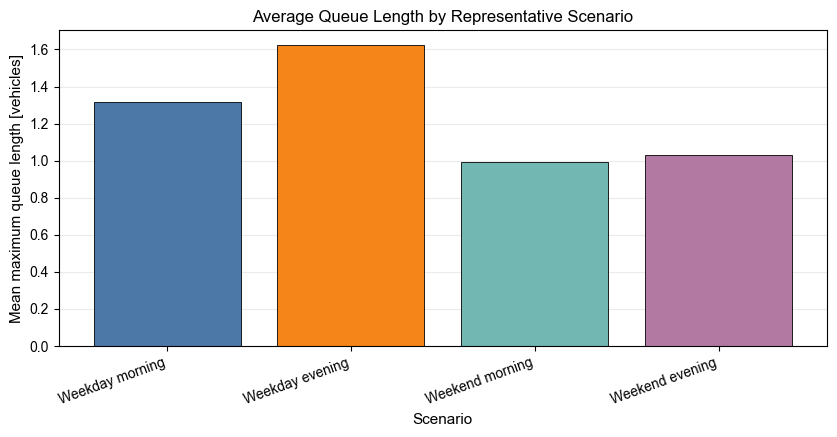

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\queue_mean_max_by_scenario.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\queue_mean_max_by_scenario.svg


In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

ax.bar(
    scenario_summary_plot["scenario_label"],
    scenario_summary_plot["meanMaxJamLengthInVehicles"],
    color=scenario_summary_plot["color"],
    edgecolor="black",
    linewidth=0.6
)

ax.set_ylabel("Mean maximum queue length [vehicles]")
ax.set_xlabel("Scenario")
ax.set_title("Average Queue Length by Representative Scenario")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig_file_png = FIG_DIR / "queue_mean_max_by_scenario.png"
fig_file_svg = FIG_DIR / "queue_mean_max_by_scenario.svg"

plt.savefig(fig_file_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_file_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(fig_file_png)
print(fig_file_svg)

### peak queue lenght by scenario 

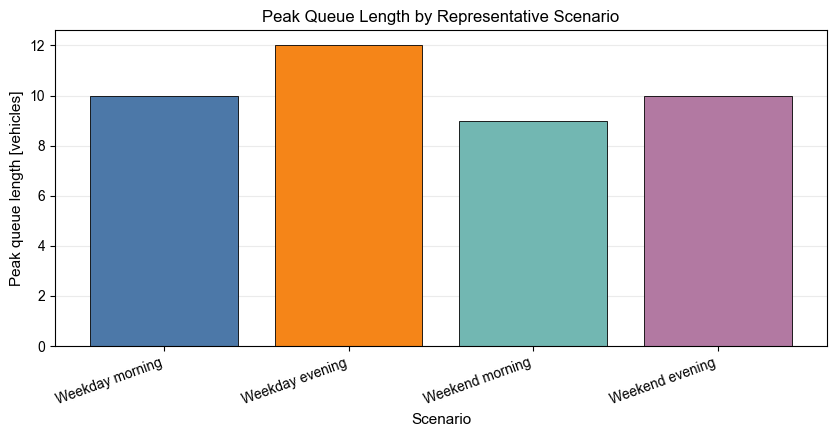

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\queue_peak_by_scenario.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\queue_peak_by_scenario.svg


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

ax.bar(
    scenario_summary_plot["scenario_label"],
    scenario_summary_plot["maxJamLengthInVehicles"],
    color=scenario_summary_plot["color"],
    edgecolor="black",
    linewidth=0.6
)

ax.set_ylabel("Peak queue length [vehicles]")
ax.set_xlabel("Scenario")
ax.set_title("Peak Queue Length by Representative Scenario")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig_file_png = FIG_DIR / "queue_peak_by_scenario.png"
fig_file_svg = FIG_DIR / "queue_peak_by_scenario.svg"

plt.savefig(fig_file_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_file_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(fig_file_png)
print(fig_file_svg)

## mean halting duration by scenario 

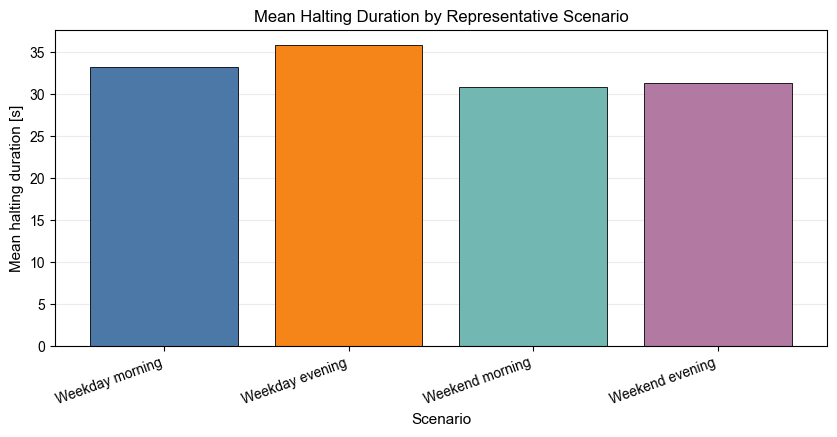

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\mean_halting_duration_by_scenario.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\mean_halting_duration_by_scenario.svg


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

ax.bar(
    scenario_summary_plot["scenario_label"],
    scenario_summary_plot["meanHaltingDuration"],
    color=scenario_summary_plot["color"],
    edgecolor="black",
    linewidth=0.6
)

ax.set_ylabel("Mean halting duration [s]")
ax.set_xlabel("Scenario")
ax.set_title("Mean Halting Duration by Representative Scenario")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig_file_png = FIG_DIR / "mean_halting_duration_by_scenario.png"
fig_file_svg = FIG_DIR / "mean_halting_duration_by_scenario.svg"

plt.savefig(fig_file_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_file_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(fig_file_png)
print(fig_file_svg)

## 15 minute queue devellopment by scenario 

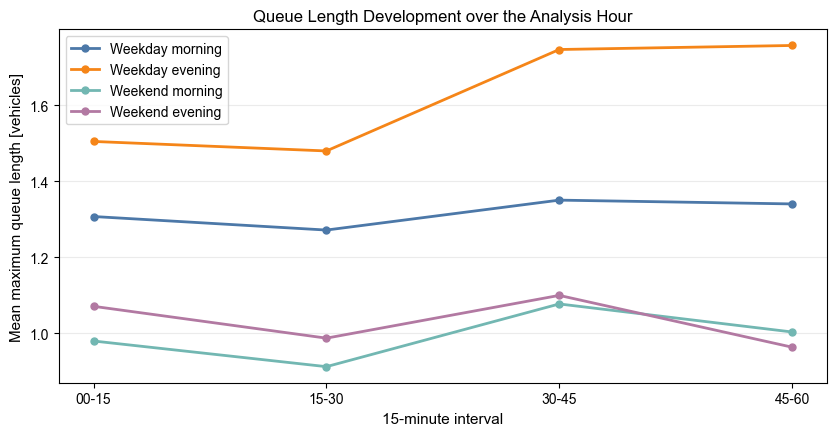

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\queue_development_15min_by_scenario.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\queue_development_15min_by_scenario.svg


In [9]:
interval_summary = (
    approach_df
    .groupby(["scenario", "bin_label"], as_index=False)
    .agg({
        "meanMaxJamLengthInVehicles": "mean"
    })
)

bin_order = ["00-15", "15-30", "30-45", "45-60"]

fig, ax = plt.subplots(figsize=(8.5, 4.5))

for scenario in SCENARIO_ORDER:
    temp = (
        interval_summary[interval_summary["scenario"] == scenario]
        .set_index("bin_label")
        .loc[bin_order]
        .reset_index()
    )

    ax.plot(
        temp["bin_label"],
        temp["meanMaxJamLengthInVehicles"],
        marker="o",
        linewidth=2,
        markersize=5,
        color=SCENARIO_COLORS[scenario],
        label=SCENARIO_LABELS[scenario]
    )

ax.set_ylabel("Mean maximum queue length [vehicles]")
ax.set_xlabel("15-minute interval")
ax.set_title("Queue Length Development over the Analysis Hour")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=True)

plt.tight_layout()

fig_file_png = FIG_DIR / "queue_development_15min_by_scenario.png"
fig_file_svg = FIG_DIR / "queue_development_15min_by_scenario.svg"

plt.savefig(fig_file_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_file_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(fig_file_png)
print(fig_file_svg)

**The reported values correspond to averaged queue intensity indicators and therefore appear lower than instantaneous peak queues. Since the E2 detector output is aggregated over time intervals and approaches, the values represent normalized operational congestion levels rather than absolute standing queue lengths observed at a single moment.**

## intersection level queue comparison

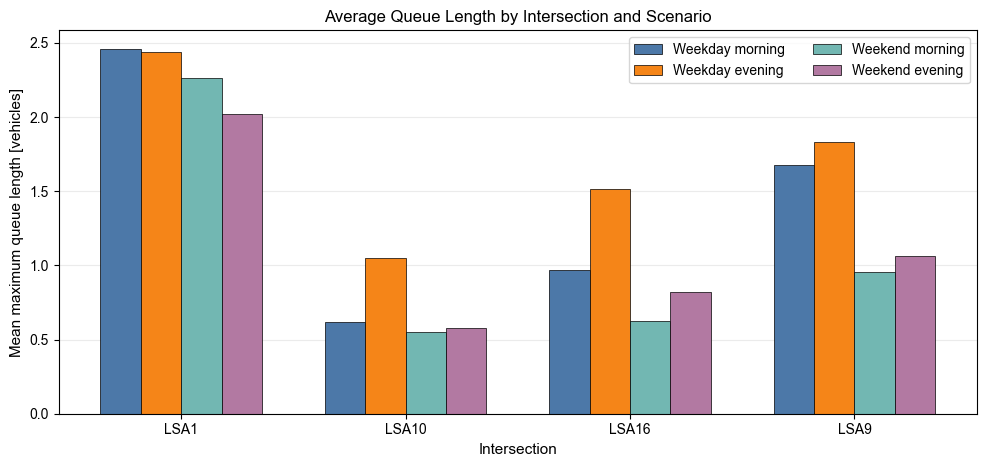

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\intersection_queue_comparison_by_scenario.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\queuelength\analysis_outputs\figures\intersection_queue_comparison_by_scenario.svg


In [10]:
intersection_summary = (
    approach_df
    .groupby(["scenario", "intersection"], as_index=False)
    .agg({
        "meanMaxJamLengthInVehicles": "mean"
    })
)

intersections = sorted(intersection_summary["intersection"].unique())
x = np.arange(len(intersections))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 4.8))

for idx, scenario in enumerate(SCENARIO_ORDER):
    temp = (
        intersection_summary[intersection_summary["scenario"] == scenario]
        .set_index("intersection")
        .reindex(intersections)
        .reset_index()
    )

    ax.bar(
        x + (idx - 1.5) * width,
        temp["meanMaxJamLengthInVehicles"],
        width=width,
        color=SCENARIO_COLORS[scenario],
        edgecolor="black",
        linewidth=0.5,
        label=SCENARIO_LABELS[scenario]
    )

ax.set_ylabel("Mean maximum queue length [vehicles]")
ax.set_xlabel("Intersection")
ax.set_title("Average Queue Length by Intersection and Scenario")
ax.set_xticks(x)
ax.set_xticklabels(intersections)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=True, ncol=2)

plt.tight_layout()

fig_file_png = FIG_DIR / "intersection_queue_comparison_by_scenario.png"
fig_file_svg = FIG_DIR / "intersection_queue_comparison_by_scenario.svg"

plt.savefig(fig_file_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_file_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(fig_file_png)
print(fig_file_svg)

The queue-related analysis was based on lane-area detector outputs placed on the incoming lanes of the signalized intersections. Since the detectors were defined at lane level, the results were aggregated to the approach level during post-processing. The first 15 minutes of the simulation were excluded as warm-up, and the remaining one-hour analysis period was evaluated in four 15-minute intervals.

The results show that queue formation was not uniformly distributed along the corridor. The weekday evening scenario produced the highest overall queue intensity, followed by the weekday morning scenario. The two weekend scenarios showed lower queue values, which is consistent with the lower expected traffic demand during these periods.

At intersection level, LSA1 and LSA9 showed the strongest queue formation. This indicates that congestion effects were mainly concentrated around selected bottlenecks rather than being evenly spread across the whole corridor. The approach-level results support this interpretation, as the highest queue intensities were observed at approaches such as LSA1_W, LSA9_NW, LSA1_E, and LSA1_N.

It should be noted that the queue length indicators were not used as direct validation metrics, because no observed queue length measurements were available for comparison. Instead, they were interpreted as simulation-based operational performance indicators. In this role, the E2 detector results complement the detector-based count and occupancy validation by providing additional information about stopping behavior, congestion concentration, and local bottlenecks within the simulated corridor.

The queue analysis indicates that the calibrated simulation does not only reproduce traffic volumes, but also produces plausible operational patterns, with higher queue formation during weekday peak conditions and localized bottlenecks at LSA1 and LSA9.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 12,
})

SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

TLS_LABELS = {
    "LSA16": "TLS16",
    "LSA10": "TLS10",
    "LSA9": "TLS9",
    "LSA1": "TLS1",
}

INTERSECTION_ORDER = ["LSA16", "LSA10", "LSA9", "LSA1"]

BIN_ORDER = ["00-15", "15-30", "30-45", "45-60"]

## Scenario × interval heatmap

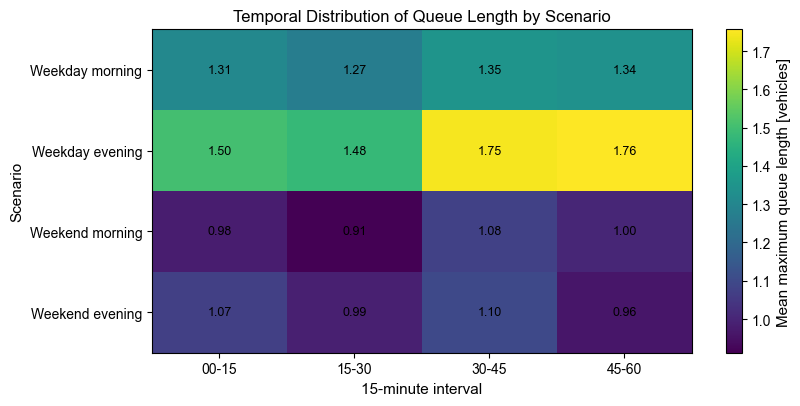

In [18]:
heatmap_df = (
    approach_df
    .groupby(["scenario", "bin_label"])["meanMaxJamLengthInVehicles"]
    .mean()
    .unstack()
    .loc[SCENARIO_ORDER, BIN_ORDER]
)

fig, ax = plt.subplots(figsize=(8.5, 4.2))

im = ax.imshow(heatmap_df.values, aspect="auto", cmap="viridis")

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels([SCENARIO_LABELS[s] for s in heatmap_df.index])

ax.set_xlabel("15-minute interval")
ax.set_ylabel("Scenario")
ax.set_title("Temporal Distribution of Queue Length by Scenario")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean maximum queue length [vehicles]")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(
            j, i,
            f"{heatmap_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

plt.tight_layout()

plt.savefig(FIG_DIR / "queue_heatmap_scenario_interval.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "queue_heatmap_scenario_interval.svg", bbox_inches="tight")
plt.show()

## Intersection × scenario heatmap

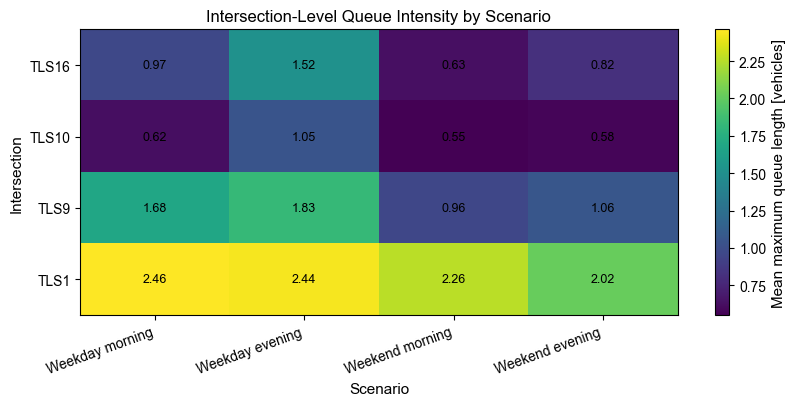

In [19]:
intersection_heatmap = (
    approach_df
    .groupby(["intersection", "scenario"])["meanMaxJamLengthInVehicles"]
    .mean()
    .unstack()
    .loc[INTERSECTION_ORDER, SCENARIO_ORDER]
)

fig, ax = plt.subplots(figsize=(8.5, 4.2))

im = ax.imshow(intersection_heatmap.values, aspect="auto", cmap="viridis")

ax.set_xticks(np.arange(len(intersection_heatmap.columns)))
ax.set_xticklabels(
    [SCENARIO_LABELS[s] for s in intersection_heatmap.columns],
    rotation=20,
    ha="right"
)

ax.set_yticks(np.arange(len(intersection_heatmap.index)))
ax.set_yticklabels([TLS_LABELS[i] for i in intersection_heatmap.index])

ax.set_xlabel("Scenario")
ax.set_ylabel("Intersection")
ax.set_title("Intersection-Level Queue Intensity by Scenario")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean maximum queue length [vehicles]")

for i in range(intersection_heatmap.shape[0]):
    for j in range(intersection_heatmap.shape[1]):
        ax.text(
            j, i,
            f"{intersection_heatmap.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

plt.tight_layout()

plt.savefig(FIG_DIR / "queue_heatmap_intersection_scenario.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "queue_heatmap_intersection_scenario.svg", bbox_inches="tight")
plt.show()

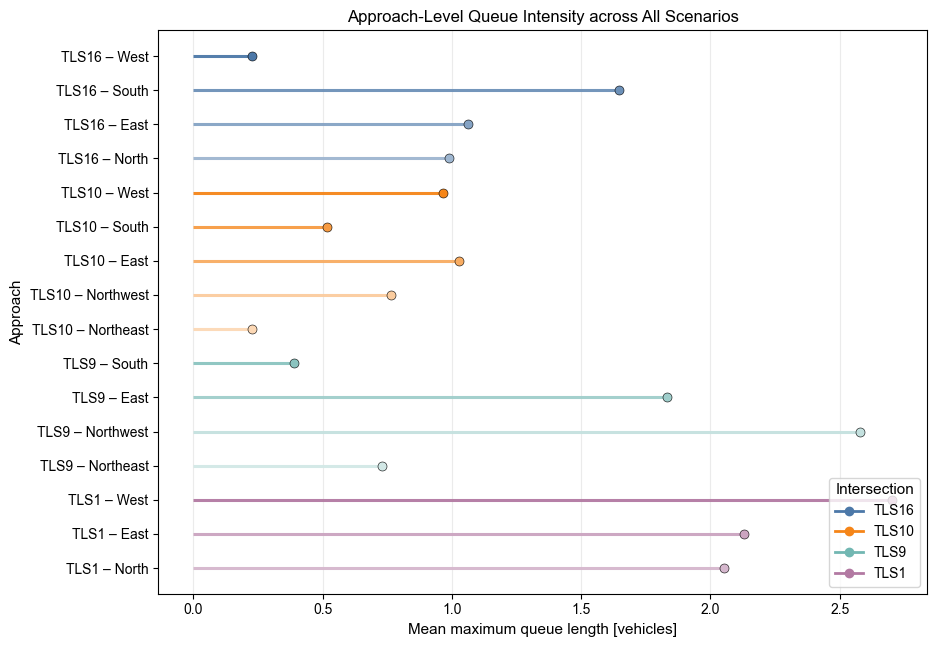

In [20]:
# ============================================================
# ORDERED APPROACH LOLLIPOP
# ============================================================

DIRECTION_LABELS = {
    "W": "West",
    "S": "South",
    "E": "East",
    "N": "North",
    "NW": "Northwest",
    "NE": "Northeast",
}

DIRECTION_ORDER = ["W", "S", "E", "N", "NW", "NE"]

BASE_COLORS = {
    "LSA16": "#4C78A8",  # blue
    "LSA10": "#F58518",  # orange
    "LSA9":  "#72B7B2",  # turquoise
    "LSA1":  "#B279A2",  # purple
}

DIRECTION_ALPHA = {
    "W": 1.00,
    "S": 0.82,
    "E": 0.68,
    "N": 0.54,
    "NW": 0.42,
    "NE": 0.32,
}


def lighten_color(hex_color, alpha_to_white):
    """
    alpha_to_white = 1.0 means original color.
    lower value means lighter color.
    """
    r, g, b = to_rgb(hex_color)
    return (
        1 - alpha_to_white * (1 - r),
        1 - alpha_to_white * (1 - g),
        1 - alpha_to_white * (1 - b),
    )


def get_direction(approach):
    return approach.split("_", 1)[1]


def readable_approach_label(approach):
    tls, direction = approach.split("_", 1)
    return f"{TLS_LABELS[tls]} – {DIRECTION_LABELS.get(direction, direction)}"


approach_lollipop = (
    approach_df
    .groupby(["intersection", "approach"], as_index=False)
    .agg({
        "meanMaxJamLengthInVehicles": "mean",
        "maxJamLengthInVehicles": "max",
        "meanHaltingDuration": "mean",
        "jamLengthInVehiclesSum": "sum"
    })
)

approach_lollipop["direction"] = approach_lollipop["approach"].apply(get_direction)

approach_lollipop["intersection_rank"] = approach_lollipop["intersection"].map(
    {tls: i for i, tls in enumerate(INTERSECTION_ORDER)}
)

approach_lollipop["direction_rank"] = approach_lollipop["direction"].map(
    {d: i for i, d in enumerate(DIRECTION_ORDER)}
)

approach_lollipop = (
    approach_lollipop
    .sort_values(["intersection_rank", "direction_rank"])
    .reset_index(drop=True)
)

approach_lollipop["plot_label"] = approach_lollipop["approach"].apply(readable_approach_label)

approach_lollipop["plot_color"] = approach_lollipop.apply(
    lambda row: lighten_color(
        BASE_COLORS[row["intersection"]],
        DIRECTION_ALPHA.get(row["direction"], 0.6)
    ),
    axis=1
)

# Reverse for top-to-bottom visual order
plot_df = approach_lollipop.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(9.5, 6.6))

for _, row in plot_df.iterrows():
    ax.hlines(
        y=row["plot_label"],
        xmin=0,
        xmax=row["meanMaxJamLengthInVehicles"],
        color=row["plot_color"],
        linewidth=2.2,
        alpha=0.95
    )

    ax.plot(
        row["meanMaxJamLengthInVehicles"],
        row["plot_label"],
        "o",
        color=row["plot_color"],
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=6.5
    )

ax.set_xlabel("Mean maximum queue length [vehicles]")
ax.set_ylabel("Approach")
ax.set_title("Approach-Level Queue Intensity across All Scenarios")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

legend_handles = [
    plt.Line2D(
        [0], [0],
        color=BASE_COLORS[tls],
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6,
        label=TLS_LABELS[tls]
    )
    for tls in INTERSECTION_ORDER
]

ax.legend(
    handles=legend_handles,
    title="Intersection",
    frameon=True,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(FIG_DIR / "queue_lollipop_ordered_approaches.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "queue_lollipop_ordered_approaches.svg", bbox_inches="tight")
plt.show()

Queue-related traffic conditions were evaluated using lane-area detectors placed on the incoming lanes of the selected signalized intersections. The detector outputs were first collected at lane level and then aggregated to the approach level. The first 15 minutes of the simulation were excluded as warm-up, while the remaining one-hour analysis period was evaluated in four 15-minute intervals.

The scenario-based heatmap shows that the weekday evening scenario produced the highest queue intensity, especially in the second half of the analysis period. The weekday morning scenario also showed visible queue formation, but at a lower level. In contrast, both weekend scenarios remained lower overall, which is consistent with the expected reduction in traffic demand outside weekday peak periods.

At the intersection level, the strongest queue formation occurred at TLS1 and TLS9. This suggests that congestion was not evenly distributed along the corridor, but concentrated at selected local bottlenecks. The approach-level lollipop plot supports this interpretation, showing that approaches such as TLS1 West, TLS9 Northwest, TLS1 East, and TLS1 North produced the highest mean maximum queue lengths across the evaluated scenarios.

Since observed queue length data were not available, the E2 detector results were not used as direct validation metrics. Instead, they were interpreted as simulation-based operational performance indicators. In this role, the queue analysis complements the count and occupancy validation by providing additional information about stopping behavior, queue formation, and the spatial concentration of congestion within the simulated corridor.

## Sceario-level operational indicator comparison

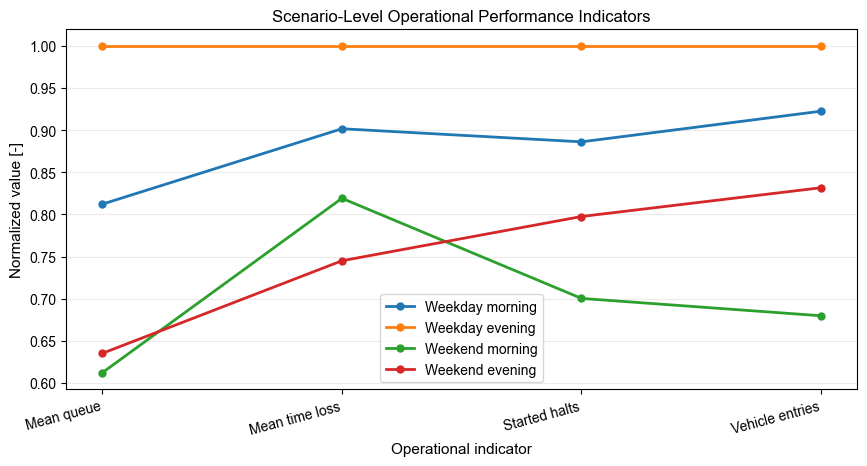

In [27]:
# ============================================================
# SCENARIO-LEVEL OPERATIONAL INDICATOR COMPARISON
# Normalized index plot
# ============================================================

indicator_cols = [
    "meanMaxJamLengthInVehicles",
    "meanTimeLoss",
    "startedHalts",
    "nVehEntered",
]

indicator_labels = {
    "meanMaxJamLengthInVehicles": "Mean queue",
    "meanTimeLoss": "Mean time loss",
    "startedHalts": "Started halts",
    "nVehEntered": "Vehicle entries",
}

norm_df = scenario_summary.set_index("scenario").loc[SCENARIO_ORDER, indicator_cols].copy()

# Normalize each indicator to its maximum
norm_df = norm_df / norm_df.max()

x = np.arange(len(indicator_cols))

fig, ax = plt.subplots(figsize=(8.8, 4.8))

for scenario in SCENARIO_ORDER:
    ax.plot(
        x,
        norm_df.loc[scenario],
        marker="o",
        linewidth=2,
        markersize=5,
        label=SCENARIO_LABELS[scenario]
    )

ax.set_xticks(x)
ax.set_xticklabels([indicator_labels[c] for c in indicator_cols], rotation=15, ha="right")
ax.set_ylabel("Normalized value [-]")
ax.set_xlabel("Operational indicator")
ax.set_title("Scenario-Level Operational Performance Indicators")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=True)

plt.tight_layout()

plt.savefig(FIG_DIR / "scenario_operational_indicators_normalized.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "scenario_operational_indicators_normalized.svg", bbox_inches="tight")
plt.show()

## approach level time loss hotspot lollipop

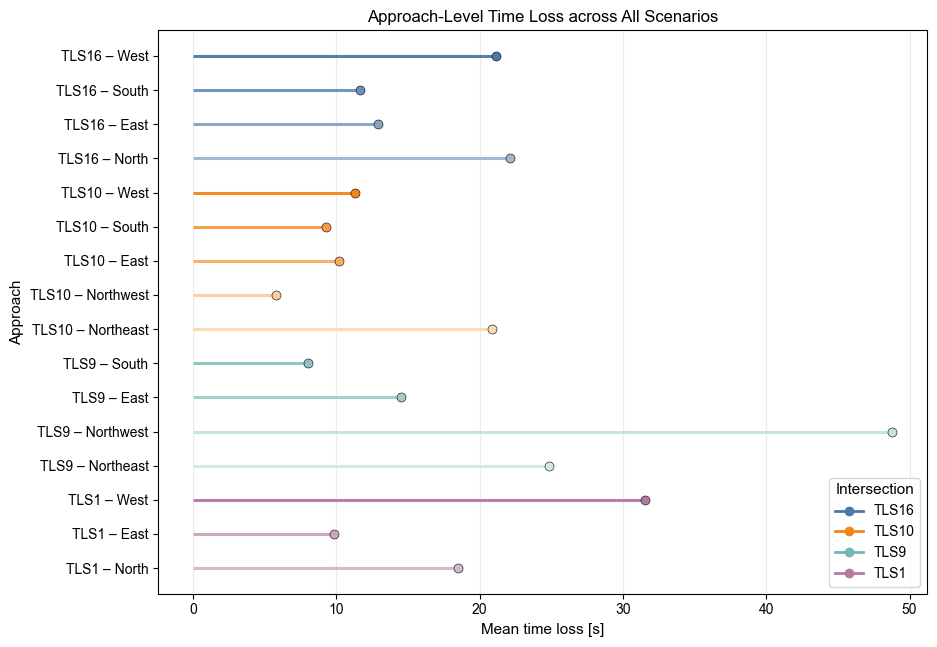

In [28]:
# ============================================================
# APPROACH-LEVEL TIME LOSS HOTSPOTS
# ============================================================

time_loss_df = approach_summary.copy()

time_loss_df["direction"] = time_loss_df["approach"].apply(lambda x: x.split("_", 1)[1])
time_loss_df["plot_label"] = time_loss_df["approach"].apply(readable_approach_label)

time_loss_df["intersection_rank"] = time_loss_df["intersection"].map(
    {tls: i for i, tls in enumerate(INTERSECTION_ORDER)}
)

time_loss_df["direction_rank"] = time_loss_df["direction"].map(
    {d: i for i, d in enumerate(DIRECTION_ORDER)}
)

time_loss_df = (
    time_loss_df
    .sort_values(["intersection_rank", "direction_rank"])
    .reset_index(drop=True)
)

time_loss_df["plot_color"] = time_loss_df.apply(
    lambda row: lighten_color(
        BASE_COLORS[row["intersection"]],
        DIRECTION_ALPHA.get(row["direction"], 0.6)
    ),
    axis=1
)

plot_df = time_loss_df.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(9.5, 6.6))

for _, row in plot_df.iterrows():
    ax.hlines(
        y=row["plot_label"],
        xmin=0,
        xmax=row["meanTimeLoss"],
        color=row["plot_color"],
        linewidth=2.2,
        alpha=0.95
    )

    ax.plot(
        row["meanTimeLoss"],
        row["plot_label"],
        "o",
        color=row["plot_color"],
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=6.5
    )

ax.set_xlabel("Mean time loss [s]")
ax.set_ylabel("Approach")
ax.set_title("Approach-Level Time Loss across All Scenarios")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

legend_handles = [
    plt.Line2D(
        [0], [0],
        color=BASE_COLORS[tls],
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6,
        label=TLS_LABELS[tls]
    )
    for tls in INTERSECTION_ORDER
]

ax.legend(
    handles=legend_handles,
    title="Intersection",
    frameon=True,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(FIG_DIR / "time_loss_lollipop_ordered_approaches.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "time_loss_lollipop_ordered_approaches.svg", bbox_inches="tight")
plt.show()

Queue and Operational Performance Analysis

Figure X shows the temporal development of the mean maximum queue length for the four representative scenarios. The results indicate that the weekday evening scenario produced the highest queue values over the analysis period. This pattern is consistent with the expected higher traffic demand during the evening peak. The weekday morning scenario also showed visible queue formation, but at a lower level. In contrast, both weekend scenarios remained lower overall, which suggests less pronounced congestion during these periods.

Figure X presents the queue intensity at intersection level. The results show that queue formation was not evenly distributed along the corridor. The highest values occurred at TLS1 and TLS9, while TLS10 and TLS16 showed lower average queue values. This indicates that congestion effects were mainly concentrated at selected local bottlenecks rather than affecting the whole corridor uniformly.

Figure X illustrates the approach-level queue intensity across all scenarios. The strongest queue formation was observed at TLS1 West, TLS9 Northwest, TLS1 East, and TLS1 North. These results support the intersection-level findings and show that the main operational constraints were linked to specific approaches. Therefore, the approach-level evaluation is useful for identifying local bottlenecks that would not be visible from scenario-level averages alone.

Figure X compares additional operational indicators at scenario level. The values were normalized to allow a direct comparison between queue length, mean time loss, started halts, and vehicle entries. The weekday evening scenario reached the highest value for all indicators, confirming that this scenario represented the strongest operational load in the simulation. The weekday morning scenario followed with slightly lower values, while the weekend scenarios showed lower queue and stop-related indicators.

Figure X shows the mean time loss at approach level. The highest value occurred at TLS9 Northwest, followed by TLS1 West and several approaches at TLS16 and TLS9. This indicates that some approaches were not only affected by longer queues, but also by stronger delay effects. The time loss results therefore complement the queue length analysis and provide additional information about local operational disturbances.

Since no observed queue length or delay measurements were available, these indicators were not used as direct validation metrics. Instead, they were interpreted as simulation-based operational performance indicators. In this role, the E2 detector results complement the detector-based count and occupancy validation by describing queue formation, stopping behaviour, and delay-related effects within the simulated corridor.


1. Scenario × interval queue heatmap
2. Intersection × scenario queue heatmap
3. Approach-level queue lollipop
4. Scenario-level operational indicator plot

appendix 5. Approach-level time loss lollipop

## tek approach icin queue + time loss lsa16 

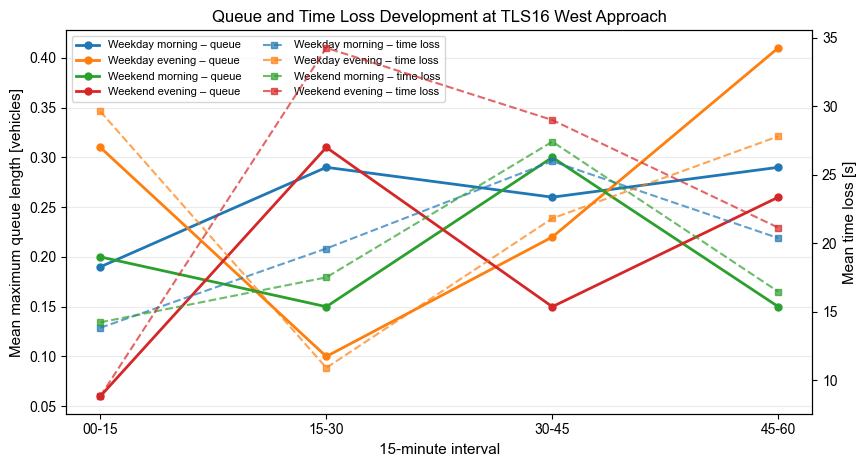

In [31]:
# ============================================================
# QUEUE AND TIME LOSS DEVELOPMENT FOR ONE APPROACH
# ============================================================

target_approach = "LSA16_W"

target_df = approach_df[approach_df["approach"] == target_approach].copy()

target_df["bin_label"] = pd.Categorical(
    target_df["bin_label"],
    categories=BIN_ORDER,
    ordered=True
)

target_df = target_df.sort_values(["scenario", "bin_label"])

fig, ax1 = plt.subplots(figsize=(8.8, 4.8))

for scenario in SCENARIO_ORDER:
    temp = target_df[target_df["scenario"] == scenario].sort_values("bin_label")

    ax1.plot(
        temp["bin_label"],
        temp["meanMaxJamLengthInVehicles"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=f"{SCENARIO_LABELS[scenario]} – queue"
    )

ax1.set_xlabel("15-minute interval")
ax1.set_ylabel("Mean maximum queue length [vehicles]")
ax1.grid(axis="y", alpha=0.25)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()

for scenario in SCENARIO_ORDER:
    temp = target_df[target_df["scenario"] == scenario].sort_values("bin_label")

    ax2.plot(
        temp["bin_label"],
        temp["meanTimeLoss"],
        marker="s",
        linewidth=1.5,
        markersize=4,
        linestyle="--",
        alpha=0.7,
        label=f"{SCENARIO_LABELS[scenario]} – time loss"
    )

ax2.set_ylabel("Mean time loss [s]")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=True,
    fontsize=8,
    ncol=2,
    loc="upper left"
)

ax1.set_title("Queue and Time Loss Development at TLS16 West Approach")

plt.tight_layout()

plt.savefig(FIG_DIR / "tls16_west_queue_time_loss_development.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "tls16_west_queue_time_loss_development.svg", bbox_inches="tight")
plt.show()